# 🎬 Video Periodicity & Contrastive Learning - Kaggle Training & Evaluation Notebook
This notebook handles repository setup, path overrides, SSL (MoCo) / SupCon training, and Anomaly Scoring / Linear Probing evaluation on Kaggle GPUs.

In [1]:
import os
import torch

# 1. Kiểm tra thiết bị GPU
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# 2. Đặt thư mục làm việc chính
WORKING_DIR = "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive"

# Nếu bạn upload source code lên Github hoặc dưới dạng Kaggle Dataset:
# %cd /kaggle/working
# !git clone <your-repo-url> video-periodicity-contrastive

# Chuyển vào thư mục mã nguồn
os.chdir(WORKING_DIR)
print(f"Current working directory: {os.getcwd()}")

CUDA Available: True
Device count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Current working directory: /kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive


In [2]:
%%bash
# Cài đặt các gói phụ thuộc (PyAV, OpenCV, Tensorboard/Wandb...)
pip install -r requirements.txt

# Nếu cần chạy smoke test dữ liệu dummy:
# python scripts/make_dummy_data.py --out /kaggle/working/dummy_data --frame-size 112

### 📂 Cấu hình Đường dẫn dữ liệu (Paths Setup)
* **KAGLE_DATA_ROOT**: Thư mục chứa video/frames (Kaggle Input).
* **KAGLE_SPLIT_DIR**: Nơi chứa các file split TXT/CSV (có thể để trong Kaggle Input hoặc `/kaggle/working`).

In [3]:
# Tên Dataset Kaggle của bạn (Thay đổi tương ứng với tên dataset bạn upload lên Kaggle)
DATASET_NAME = "my-video-dataset" 

# Kiểm tra nếu chạy bằng Dữ liệu thật hay Dữ liệu Dummy Smoke Test
USE_DUMMY = False 

if USE_DUMMY:
    DATA_ROOT = "/kaggle/working/dummy_data"
    TRAIN_SSL_SPLIT = "/kaggle/working/dummy_data/splits/unlabeled_train.txt"
    TRAIN_SUPCON_SPLIT = "/kaggle/working/dummy_data/splits/labeled_train.csv"
    VAL_SUPCON_SPLIT = "/kaggle/working/dummy_data/splits/labeled_val.csv"
    NORMAL_EVAL_SPLIT = "/kaggle/working/dummy_data/splits/normal_train.txt"
    TEST_EVAL_SPLIT = "/kaggle/working/dummy_data/splits/test.csv"
else:
    DATA_ROOT = f"/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data"
    TRAIN_SSL_SPLIT = f"{DATA_ROOT}/splits/unlabeled_train.txt"
    TRAIN_SUPCON_SPLIT = f"{DATA_ROOT}/splits/labeled_train.csv"
    VAL_SUPCON_SPLIT = f"{DATA_ROOT}/splits/labeled_val.csv"
    NORMAL_EVAL_SPLIT = f"{DATA_ROOT}/splits/normal_train.txt"
    TEST_EVAL_SPLIT = f"{DATA_ROOT}/splits/test.csv"

BACKBONE = "resnet3d_18"
OUTPUT_DIR = "/kaggle/working/runs"

CHECKPOINT_DIR = "/kaggle/input/datasets/trangdngminh/asd-contrastive-output/runs"

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

DATA_ROOT: /kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data
OUTPUT_DIR: /kaggle/working/runs


## 🚀 1. Self-Supervised Learning (SSL - MoCo) Pretraining
Chạy MoCo v2 với Speed Warp và Frame Shuffle. 
Sử dụng CLI overrides `--opts` để ghi đè cấu hình trong `configs/ssl_moco.yaml` mà không cần sửa file trực tiếp[cite: 1, 2].

In [4]:
import subprocess

print(f"🚀 Executing SSL MoCo Training...")

# Chạy trực tiếp trong Cell Python (không dùng %%bash)
ssl_cmd = f"""
python -m torch.distributed.run --nproc_per_node=gpu train.py --config configs/ssl_moco.yaml --opts backbone.name={BACKBONE} data.root={DATA_ROOT} data.train_split={TRAIN_SSL_SPLIT} data.num_workers=2 output_dir={OUTPUT_DIR} optim.batch_size=8 optim.epochs=50
"""

subprocess.run(ssl_cmd, shell=True, check=True)

🚀 Executing SSL MoCo Training...



*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
W0906 13:50:52.742000 113 torch/distributed/elastic/agent/server/api.py:739] Received 2 death signal, shutting down workers
W0906 13:50:52.743000 113 torch/distributed/elastic/multiprocessing/api.py:1010] Sending process 120 closing signal SIGINT
W0906 13:50:52.745000 113 torch/distributed/elastic/multiprocessing/api.py:1010] Sending process 121 closing signal SIGINT
Traceback (most recent call last):
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/train.py", line 24, in <module>
Traceback (most recent call last):
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/train.py", line 24, in <module>
    from trainers.ssl_trainer import SS

KeyboardInterrupt: 

## 🎯 2. Supervised Contrastive Learning (SupCon) Training
Chạy SupCon với nhãn hành vi (`0 = non-ASD`, `1 = ASD/stimming`).

In [ ]:
import subprocess

print(f"🎯 Executing SupCon Training...")

supcon_cmd = f"""
python -m torch.distributed.run --nproc_per_node=gpu train.py --config configs/supcon.yaml --opts backbone.name={BACKBONE} data.root={DATA_ROOT} data.train_split={TRAIN_SUPCON_SPLIT} data.num_workers=2 output_dir={OUTPUT_DIR} optim.batch_size=8 optim.epochs=50
"""

subprocess.run(supcon_cmd, shell=True, check=True)

## 📊 3. Downstream Evaluation: Anomaly Scoring (K-Centroids)
- **Stage 2**: Mining K-Centroids trên tập clips bình thường (`normal_split`)[cite: 1, 3].
- **Stage 3**: Inference cửa sổ trượt (sliding window) trên tập `test_split` và tính AUC-ROC / EER / FAR-ratio[cite: 1, 3].

In [5]:
import subprocess

print(f"📊 Executing Anomaly Scoring - SSL Evaluation...")

eval_anomaly_ssl_cmd = f"""
python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} checkpoint_path={CHECKPOINT_DIR}/ssl_moco/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split={NORMAL_EVAL_SPLIT} eval.centroids.save_path={OUTPUT_DIR}/ssl_moco/centroids.pth eval.test_split={TEST_EVAL_SPLIT} visualize.out_dir={OUTPUT_DIR}/ssl_moco/plots
"""

subprocess.run(eval_anomaly_ssl_cmd, shell=True, check=True)

📊 Executing Anomaly Scoring - SSL Evaluation...
[eval] mined 20 centroids from 45 normal clips -> /kaggle/working/runs/ssl_moco/centroids.pth
[eval] frame-level metrics over 12 videos: {'eer': 0.40456506699091743, 'far_ratio': 0.0, 'micro_auc_roc': 0.6237672178806479, 'macro_auc_roc': 0.61517686781376}


Traceback (most recent call last):
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/eval.py", line 301, in <module>
    main()
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/eval.py", line 293, in main
    run_anomaly_scoring(cfg, device)
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/eval.py", line 176, in run_anomaly_scoring
    with open(out_path, "w") as f:
         ^^^^^^^^^^^^^^^^^^^
OSError: [Errno 30] Read-only file system: '/kaggle/input/datasets/trangdngminh/asd-contrastive-output/runs/ssl_moco/anomaly_scoring_results.json'


CalledProcessError: Command '
python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data data.num_workers=2 backbone.name=resnet3d_18 checkpoint_path=/kaggle/input/datasets/trangdngminh/asd-contrastive-output/runs/ssl_moco/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/normal_train.txt eval.centroids.save_path=/kaggle/working/runs/ssl_moco/centroids.pth eval.test_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/test.csv visualize.out_dir=/kaggle/working/runs/ssl_moco/plots
' returned non-zero exit status 1.

In [6]:
import subprocess

print(f"📊 Executing Anomaly Scoring - SupCon Evaluation...")

eval_anomaly_supcon_cmd = f"""
python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} checkpoint_path={CHECKPOINT_DIR}/supcon/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split={NORMAL_EVAL_SPLIT} eval.centroids.save_path={OUTPUT_DIR}/supcon/centroids.pth eval.test_split={TEST_EVAL_SPLIT} visualize.out_dir={OUTPUT_DIR}/supcon/plots
"""

subprocess.run(eval_anomaly_supcon_cmd, shell=True, check=True)

📊 Executing Anomaly Scoring - SupCon Evaluation...


Traceback (most recent call last):
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/eval.py", line 301, in <module>
    main()
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/eval.py", line 293, in main
    run_anomaly_scoring(cfg, device)
  File "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/eval.py", line 176, in run_anomaly_scoring
    with open(out_path, "w") as f:
         ^^^^^^^^^^^^^^^^^^^
OSError: [Errno 30] Read-only file system: '/kaggle/input/datasets/trangdngminh/asd-contrastive-output/runs/supcon/anomaly_scoring_results.json'


[eval] mined 20 centroids from 45 normal clips -> /kaggle/working/runs/supcon/centroids.pth
[eval] frame-level metrics over 12 videos: {'eer': 0.4752503764177586, 'far_ratio': 0.0, 'micro_auc_roc': 0.5147160136171778, 'macro_auc_roc': 0.5824364907769048}


CalledProcessError: Command '
python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data data.num_workers=2 backbone.name=resnet3d_18 checkpoint_path=/kaggle/input/datasets/trangdngminh/asd-contrastive-output/runs/supcon/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/normal_train.txt eval.centroids.save_path=/kaggle/working/runs/supcon/centroids.pth eval.test_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/test.csv visualize.out_dir=/kaggle/working/runs/supcon/plots
' returned non-zero exit status 1.

## 📈 4. Downstream Evaluation: Linear Probing
Đóng đóng băng (freeze) backbone encoder và chỉ train `ClassificationHead`[cite: 1, 3].

In [ ]:
# import subprocess

# print(f"📈 Executing Linear Probing Evaluation...")

# eval_linear_cmd = f"""
# python eval.py --config configs/eval.yaml --mode linear_probing --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} checkpoint_path={OUTPUT_DIR}/supcon/ckpt_last.pth eval.linear_probe.train_split={TRAIN_SUPCON_SPLIT} eval.linear_probe.val_split={VAL_SUPCON_SPLIT} eval.linear_probe.batch_size=16 eval.linear_probe.epochs=5
# """

# subprocess.run(eval_linear_cmd, shell=True, check=True)

Found 13 generated plots in /kaggle/working/runs/ssl_moco/plots:


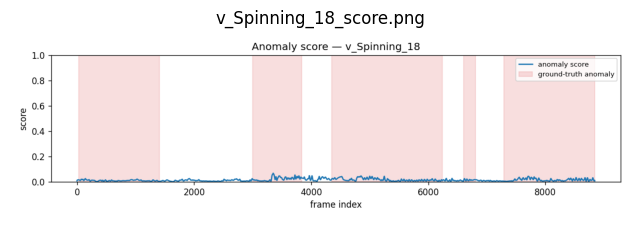

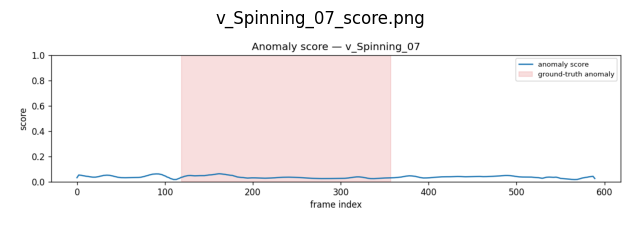

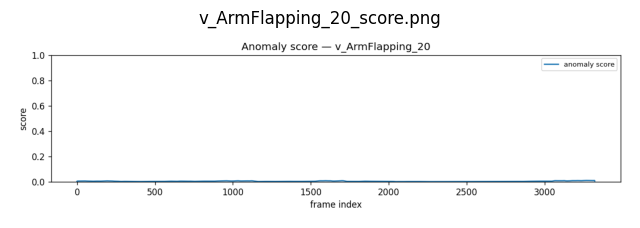

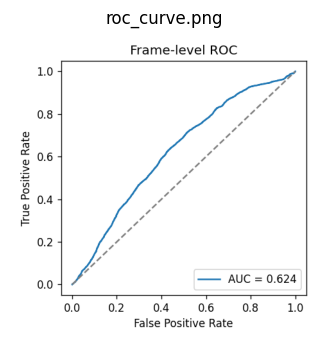

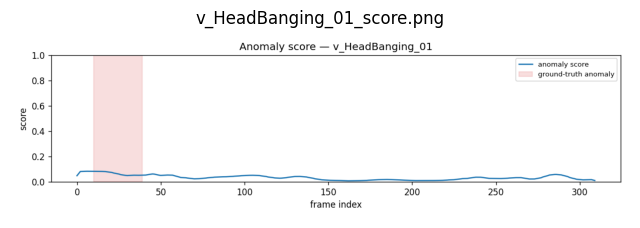

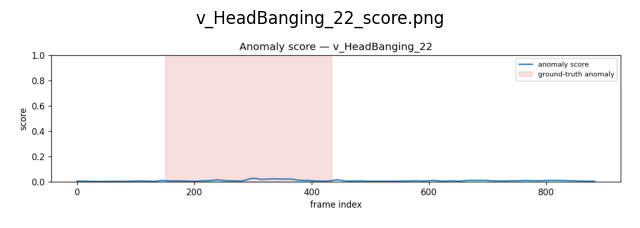

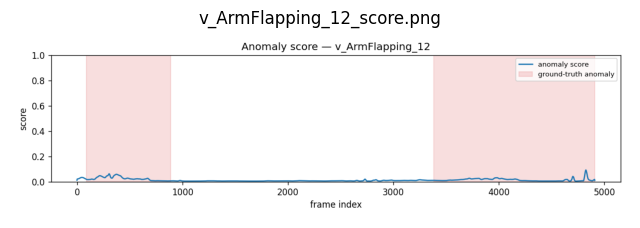

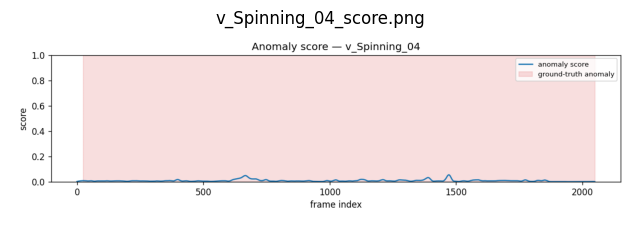

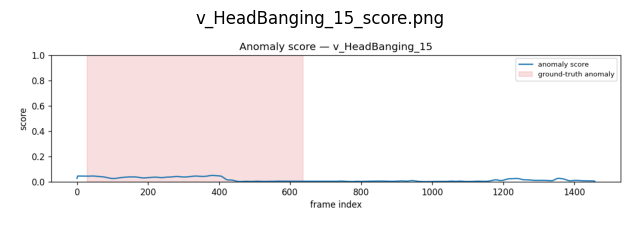

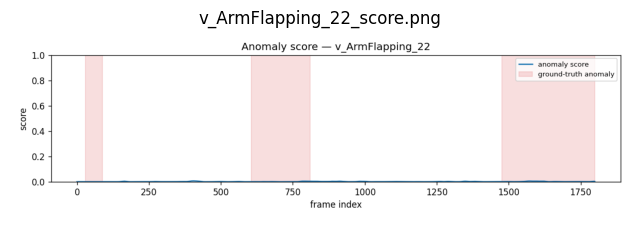

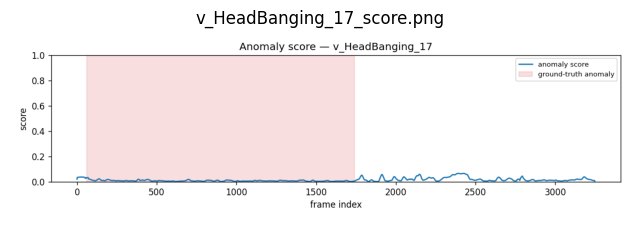

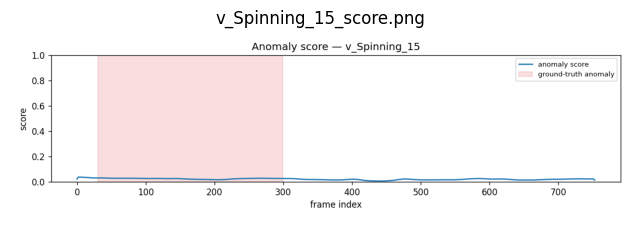

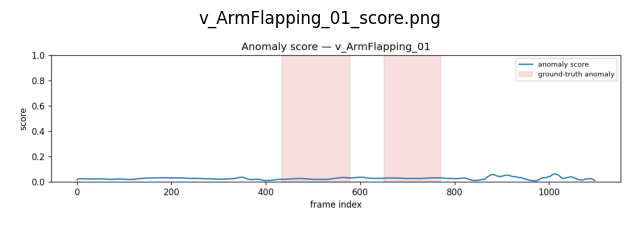

In [7]:
import os
from PIL import Image
import matplotlib.pyplot as plt

PLOT_DIR = "/kaggle/working/runs/ssl_moco/plots"

if os.path.exists(PLOT_DIR):
    plot_files = [f for f in os.listdir(PLOT_DIR) if f.endswith(('.png', '.jpg'))]
    print(f"Found {len(plot_files)} generated plots in {PLOT_DIR}:")
    
    for p in plot_files:
        img_path = os.path.join(PLOT_DIR, p)
        img = Image.open(img_path)
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.title(p)
        plt.axis('off')
        plt.show()
else:
    print("No plots folder found yet.")